# **Satellite Land Use Classification using CNN, Grad-CAM, and AI-Assisted Interpretation**
## **Deep Learning With Pytorch**
---


**Objective:**

---

The goal of this project is to automatically classify different types of land use (such as forests, rivers, highways, and residential areas) from satellite images using deep learning techniques. The project also aims to provide visual and AI-based explanations to better understand how the model makes its predictions.





**Dataset Description:**

---

The project uses the EuroSAT dataset, which contains approximately 27,000 satellite images captured by the Sentinel-2 satellite. The dataset is divided into 10 land use categories, including Annual Crop, Forest, Herbaceous Vegetation, Highway, Industrial, Pasture, Permanent Crop, Residential, River, and SeaLake. Each image has a resolution of 64×64 pixels, which allows for efficient model training while still preserving important visual features needed for classification.


https://www.kaggle.com/datasets/apollo2506/eurosat-dataset

**Problem Statement:**

---


Satellite images contain valuable information about land use, but manually analyzing large amounts of data is time-consuming and inefficient. This project aims to automate land use classification using deep learning, making the process faster and more scalable.

###1. Dataset Setup - Downloading EuroSAT Dataset from Kaggle

In [ ]:
!pip install -q kaggle

In [ ]:
import os
from google.colab import userdata

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

In [ ]:
#Download and unzip dataset
if not os.path.exists("/content/EuroSAT"):
    !kaggle datasets download -d apollo2506/eurosat-dataset
    !unzip -q -o eurosat-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset
License(s): CC0-1.0
100% 2.04G/2.04G [02:04<00:00, 17.6MB/s]



In [ ]:
import os
#check folders
print(os.listdir("/content"))

['.config', 'eurosat-dataset.zip', 'EuroSAT', 'EuroSATallBands', 'sample_data']


In [ ]:
print(os.listdir("/content/EuroSAT"))

['train.csv', 'Residential', 'SeaLake', 'River', 'Highway', 'validation.csv', 'PermanentCrop', 'label_map.json', 'HerbaceousVegetation', 'AnnualCrop', 'Forest', 'Industrial', 'Pasture', 'test.csv']


###2. Loading Dataset - SimpleCNN and ResNet

In [ ]:
from torchvision import datasets, transforms

In [ ]:
#reads images from the EuroSAT folder
#gets class names from folder names
#resizes images to a fixed size
#converts images into PyTorch tensors
data_dir = "/content/EuroSAT"

#Transform for SimpleCNN
transform_cnn = transforms.Compose([
    transforms.Resize((64, 64)),  #Ensure consistent input size
    transforms.ToTensor(),        #Convert pixels to tensors
    transforms.Normalize(         #Standardize color distribution
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

#Transform for ResNet
transform_resnet = transforms.Compose([
    transforms.Resize((224, 224)),  #IMPORTANT CHANGE
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = datasets.ImageFolder(root=data_dir, transform=transform_cnn)

print("Total images:", len(dataset))
print("Classes:", dataset.classes)
print("Class to index mapping:", dataset.class_to_idx)


Total images: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Class to index mapping: {'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


In [ ]:
#split dataset into train/val/test
from torch.utils.data import random_split
import torch

In [ ]:
#split the dataset into 70% training, 15% val, and 15% testing.
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))

test_size = len(dataset) - train_size - val_size

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=generator)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 18900
Validation size: 4050
Test size: 4050


In [ ]:
#ResNet dataset (uses 224x224 images)
dataset_resnet = datasets.ImageFolder(root=data_dir, transform=transform_resnet)

#Same split sizes for ResNet
train_dataset_resnet, val_dataset_resnet, test_dataset_resnet = random_split(
    dataset_resnet,
    [train_size, val_size, test_size],
    generator=generator
)

print("ResNet Train size:", len(train_dataset_resnet))
print("ResNet Validation size:", len(val_dataset_resnet))
print("ResNet Test size:", len(test_dataset_resnet))

ResNet Train size: 18900
ResNet Validation size: 4050
ResNet Test size: 4050


In [ ]:
#dataLoader helps load data in batches so the model can train efficiently.
from torch.utils.data import DataLoader

In [ ]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 591
Validation batches: 127
Test batches: 127


In [ ]:
#DataLoaders for ResNet (224x224 images)
batch_size = 32

train_loader_resnet = DataLoader(train_dataset_resnet, batch_size=batch_size, shuffle=True)
val_loader_resnet = DataLoader(val_dataset_resnet, batch_size=batch_size, shuffle=False)
test_loader_resnet = DataLoader(test_dataset_resnet, batch_size=batch_size, shuffle=False)

print("ResNet Train batches:", len(train_loader_resnet))
print("ResNet Validation batches:", len(val_loader_resnet))
print("ResNet Test batches:", len(test_loader_resnet))

ResNet Train batches: 591
ResNet Validation batches: 127
ResNet Test batches: 127


In [ ]:
import torch

In [ ]:
#confirms the dataloader is giving me the data in the correct shape before building the model
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Sample labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 64, 64])
Label batch shape: torch.Size([32])
Sample labels: tensor([2, 0, 9, 7, 1, 7, 4, 3, 2, 1])


In [ ]:
#check ResNet input shape
images_resnet, labels_resnet = next(iter(train_loader_resnet))

print("ResNet Image batch shape:", images_resnet.shape)
print("ResNet Label batch shape:", labels_resnet.shape)

#verify both models receive correct input sizes

ResNet Image batch shape: torch.Size([32, 3, 224, 224])
ResNet Label batch shape: torch.Size([32])


###3. CNN Model base

In [ ]:
import torch.nn as nn

In [ ]:
#builds a simple CNN for image classification
#extracts features using convolution + pooling layers
#classifies images into 10 classes
#now that the data is ready, i need a first model to learn patterns from the images
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), #Convolution Layer 1
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   #Pooling Layer 1

            nn.Conv2d(32, 64, kernel_size=3, padding=1), #Convolution Layer 2
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  #Pooling Layer 2

            nn.Conv2d(64, 128, kernel_size=3, padding=1), #Convolution Layer 3
            nn.ReLU(),
            nn.MaxPool2d(2, 2)    #Pooling Layer 3
        )
        #classification layers
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),    #Fully Connected Layer 1
            nn.ReLU(),
            nn.Dropout(0.5),                #Randomly disables neurons to improve learning
            nn.Linear(256, num_classes)     #Fully Connected Output Layer
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


simple_cnn_model = SimpleCNN(num_classes=10)
print(simple_cnn_model)

#created the first CNN model
#3 convolution layers → extract features
#fully connected layers → classify into 10 classes

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


###4. ResNet Model

In [ ]:
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn

# Load pretrained ResNet18
resnet_model = resnet18(weights=ResNet18_Weights.DEFAULT)

# Modify final layer
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 10)

resnet_model = resnet_model.to(device)

print("ResNet18 model ready")
print("Final layer:", resnet_model.fc)

ResNet18 model ready
Final layer: Linear(in_features=512, out_features=10, bias=True)


###5. Loss + Optimizer

In [ ]:
#loss function, optimizer for CNN
import torch.optim as optim

In [ ]:
model = SimpleCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [ ]:
#Loss function and optimizer for ResNet
criterion_resnet = nn.CrossEntropyLoss()
optimizer_resnet = optim.Adam(resnet_model.parameters(), lr=0.001)

print("ResNet Loss function:", criterion_resnet)
print("ResNet Optimizer:", optimizer_resnet)

ResNet Loss function: CrossEntropyLoss()
ResNet Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


###6. Training the CNN model

In [ ]:
import torch

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Using device:", device)

Using device: cuda


In [ ]:
#move ResNet model to the same device
resnet_model = resnet_model.to(device)

print("ResNet using device:", device)

ResNet using device: cuda


In [ ]:
#set how many times the model will learn from the full training dataset
#also create lists to store loss and accuracy for later analysis and plots
#cnn training setup
num_epochs = 10

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

In [ ]:
#Tracking metrics for ResNet
train_losses_resnet = []
val_losses_resnet = []
train_accuracies_resnet = []
val_accuracies_resnet = []

In [ ]:
#Start the training process for a set number of epochs
for epoch in range(num_epochs):
    #Training
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    #Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")

Epoch [1/10] Train Loss: 1.0852, Train Acc: 60.06% | Val Loss: 0.6415, Val Acc: 77.56%
Epoch [2/10] Train Loss: 0.6889, Train Acc: 76.02% | Val Loss: 0.5438, Val Acc: 79.73%
Epoch [3/10] Train Loss: 0.5525, Train Acc: 80.87% | Val Loss: 0.5376, Val Acc: 81.09%
Epoch [4/10] Train Loss: 0.4509, Train Acc: 84.37% | Val Loss: 0.4183, Val Acc: 85.36%
Epoch [5/10] Train Loss: 0.3854, Train Acc: 86.68% | Val Loss: 0.3562, Val Acc: 88.05%
Epoch [6/10] Train Loss: 0.3028, Train Acc: 89.81% | Val Loss: 0.3154, Val Acc: 89.53%
Epoch [7/10] Train Loss: 0.2758, Train Acc: 90.83% | Val Loss: 0.3467, Val Acc: 88.17%
Epoch [8/10] Train Loss: 0.2196, Train Acc: 92.61% | Val Loss: 0.3091, Val Acc: 90.25%
Epoch [9/10] Train Loss: 0.1887, Train Acc: 93.59% | Val Loss: 0.3107, Val Acc: 89.90%
Epoch [10/10] Train Loss: 0.1526, Train Acc: 95.04% | Val Loss: 0.3113, Val Acc: 91.23%


In [ ]:
#Start the training process for ResNet
for epoch in range(num_epochs):
    # Training
    resnet_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader_resnet:
        images, labels = images.to(device), labels.to(device)

        optimizer_resnet.zero_grad()
        outputs = resnet_model(images)
        loss = criterion_resnet(outputs, labels)
        loss.backward()
        optimizer_resnet.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader_resnet)
    train_accuracy = 100 * correct / total

    # Validation
    resnet_model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader_resnet:
            images, labels = images.to(device), labels.to(device)

            outputs = resnet_model(images)
            loss = criterion_resnet(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader_resnet)
    val_accuracy = 100 * val_correct / val_total

    train_losses_resnet.append(train_loss)
    val_losses_resnet.append(val_loss)
    train_accuracies_resnet.append(train_accuracy)
    val_accuracies_resnet.append(val_accuracy)

    print(f"ResNet Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")

ResNet Epoch [1/10] Train Loss: 0.4639, Train Acc: 85.15% | Val Loss: 0.2810, Val Acc: 90.72%
ResNet Epoch [2/10] Train Loss: 0.2542, Train Acc: 91.82% | Val Loss: 0.1825, Val Acc: 94.10%
ResNet Epoch [3/10] Train Loss: 0.1938, Train Acc: 93.61% | Val Loss: 0.1835, Val Acc: 94.00%
ResNet Epoch [4/10] Train Loss: 0.1783, Train Acc: 94.14% | Val Loss: 0.1470, Val Acc: 95.33%
ResNet Epoch [5/10] Train Loss: 0.1342, Train Acc: 95.58% | Val Loss: 0.2293, Val Acc: 93.14%
ResNet Epoch [6/10] Train Loss: 0.1254, Train Acc: 95.79% | Val Loss: 0.1477, Val Acc: 95.41%
ResNet Epoch [7/10] Train Loss: 0.1020, Train Acc: 96.51% | Val Loss: 0.1083, Val Acc: 96.54%
ResNet Epoch [8/10] Train Loss: 0.0908, Train Acc: 96.92% | Val Loss: 0.1478, Val Acc: 95.68%
ResNet Epoch [9/10] Train Loss: 0.0813, Train Acc: 97.25% | Val Loss: 0.1339, Val Acc: 95.63%
ResNet Epoch [10/10] Train Loss: 0.0774, Train Acc: 97.44% | Val Loss: 0.2036, Val Acc: 93.73%


###7. Test data evaluation

Evaluate both models separately using their own test loaders

In [ ]:
#Set the model to evaluation mode for cnn
model.eval()
test_correct = 0
test_total = 0

#Disable gradient calculation to save memory and speed up the process
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_accuracy = 100 * test_correct / test_total
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 90.81%


In [ ]:
#Evaluate ResNet on test data
resnet_model.eval()
test_correct_resnet = 0
test_total_resnet = 0

with torch.no_grad():
    for images, labels in test_loader_resnet:
        images, labels = images.to(device), labels.to(device)

        outputs = resnet_model(images)
        _, predicted = torch.max(outputs, 1)

        test_total_resnet += labels.size(0)
        test_correct_resnet += (predicted == labels).sum().item()

test_accuracy_resnet = 100 * test_correct_resnet / test_total_resnet
print(f"ResNet Test Accuracy: {test_accuracy_resnet:.2f}%")

ResNet Test Accuracy: 94.12%


The ResNet model outperformed the baseline CNN, achieving a test accuracy of 94.12% compared to 90.81%.

This demonstrates the advantage of transfer learning in improving model performance.

###8. Visualize Training Performance

In [ ]:
#visualize how the model improved over time.
import matplotlib.pyplot as plt

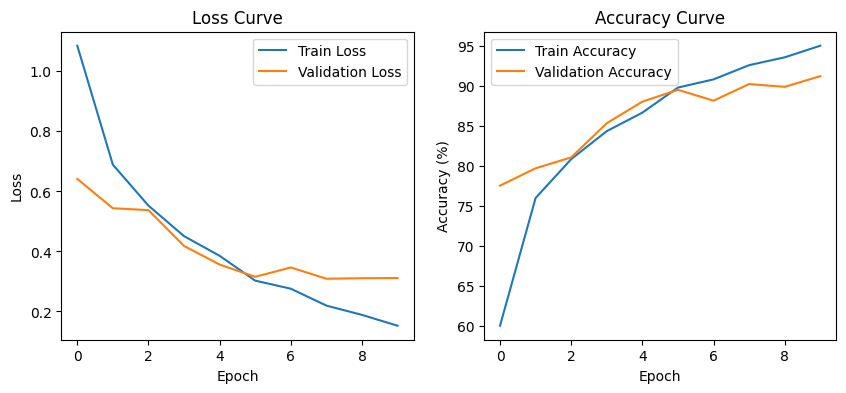

In [ ]:
#loss plot
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

#accuracy plot
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()

plt.show()

Loss is decreasing for both training and validation, the model is learning.

Accuracy is increasing, performance is improving.

Training and validation curves are close, no major overfitting.

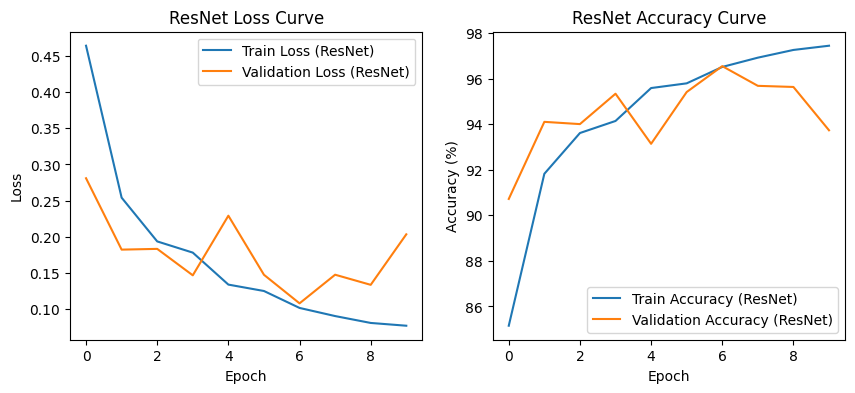

In [ ]:
#Visualize ResNet Training Performance

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

#Loss plot
plt.subplot(1, 2, 1)
plt.plot(train_losses_resnet, label="Train Loss (ResNet)")
plt.plot(val_losses_resnet, label="Validation Loss (ResNet)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet Loss Curve")
plt.legend()

#Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(train_accuracies_resnet, label="Train Accuracy (ResNet)")
plt.plot(val_accuracies_resnet, label="Validation Accuracy (ResNet)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ResNet Accuracy Curve")
plt.legend()

plt.show()

The ResNet model converges faster and achieves higher accuracy.Also, ResNet achieves peak performance early and shows slight overfitting later.


###9.Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

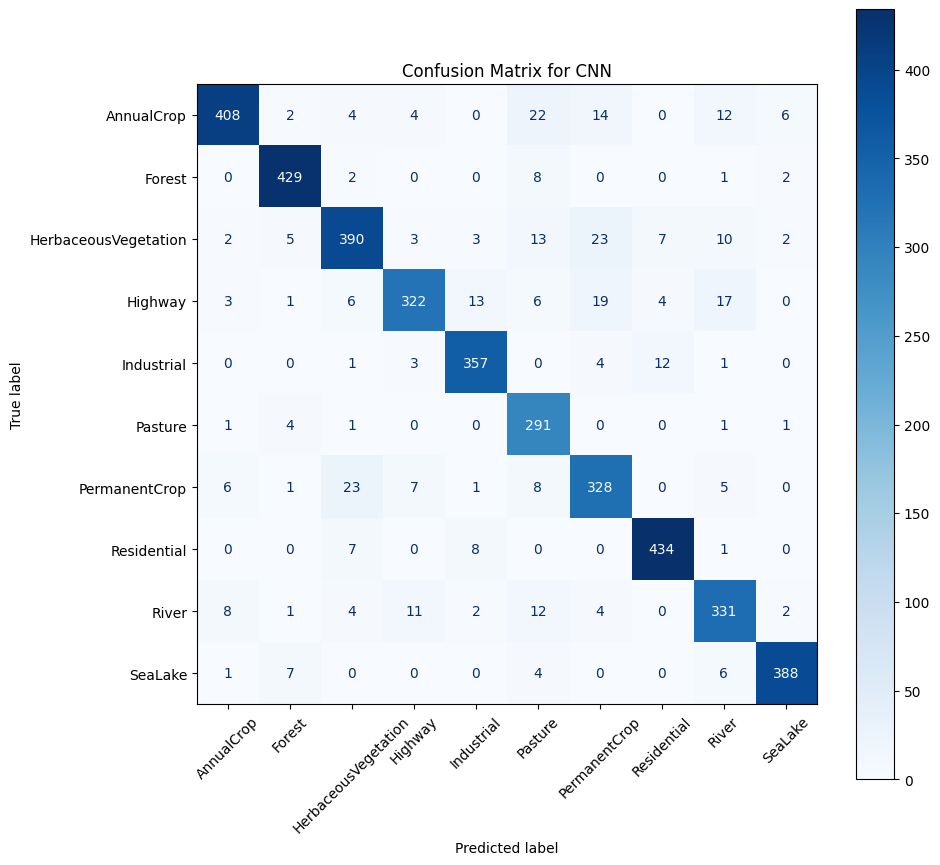

In [ ]:
#Initialize lists to store all predictions and actual labels
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

#Generate the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.classes)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues")
plt.title("Confusion Matrix for CNN")
plt.show()

The confusion matrix shows how well the model performs across all 10 classes.
For the SimpleCNN model, most predictions are correct, visible along the diagonal, but there are some misclassifications between visually similar classes such as Highway and Residential, and between different vegetation categories.

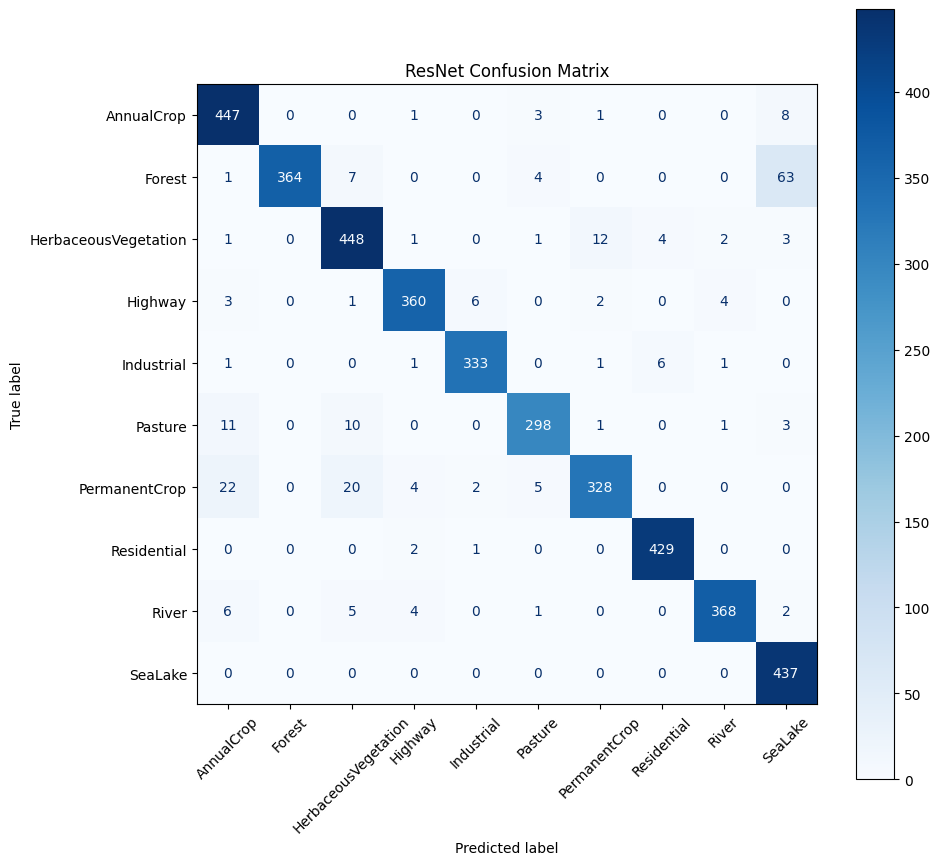

In [ ]:
#Confusion Matrix for ResNet
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

#Initialize lists
all_preds_resnet = []
all_labels_resnet = []

resnet_model.eval()
with torch.no_grad():
    for images, labels in test_loader_resnet:
        images, labels = images.to(device), labels.to(device)
        outputs = resnet_model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds_resnet.extend(predicted.cpu().numpy())
        all_labels_resnet.extend(labels.cpu().numpy())

#Generate confusion matrix
cm_resnet = confusion_matrix(all_labels_resnet, all_preds_resnet)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_resnet, display_labels=dataset.classes)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues")
plt.title("ResNet Confusion Matrix")
plt.show()

The ResNet model shows a much stronger diagonal, indicating more accurate predictions across classes. It significantly reduces confusion, especially for similar land types, and performs very well on distinct classes like SeaLake and Residential.

###10.Classification Report

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(all_labels, all_preds, target_names=dataset.classes)
print(report)

                      precision    recall  f1-score   support

          AnnualCrop       0.95      0.86      0.91       472
              Forest       0.95      0.97      0.96       442
HerbaceousVegetation       0.89      0.85      0.87       458
             Highway       0.92      0.82      0.87       391
          Industrial       0.93      0.94      0.94       378
             Pasture       0.80      0.97      0.88       299
       PermanentCrop       0.84      0.87      0.85       379
         Residential       0.95      0.96      0.96       450
               River       0.86      0.88      0.87       375
             SeaLake       0.97      0.96      0.96       406

            accuracy                           0.91      4050
           macro avg       0.91      0.91      0.91      4050
        weighted avg       0.91      0.91      0.91      4050



In [ ]:
#classification report for ResNet
from sklearn.metrics import classification_report

report_resnet = classification_report(all_labels_resnet, all_preds_resnet, target_names=dataset.classes)
print(report_resnet)

                      precision    recall  f1-score   support

          AnnualCrop       0.91      0.97      0.94       460
              Forest       1.00      0.83      0.91       439
HerbaceousVegetation       0.91      0.95      0.93       472
             Highway       0.97      0.96      0.96       376
          Industrial       0.97      0.97      0.97       343
             Pasture       0.96      0.92      0.94       324
       PermanentCrop       0.95      0.86      0.90       381
         Residential       0.98      0.99      0.99       432
               River       0.98      0.95      0.97       386
             SeaLake       0.85      1.00      0.92       437

            accuracy                           0.94      4050
           macro avg       0.95      0.94      0.94      4050
        weighted avg       0.94      0.94      0.94      4050



###11. Saving the Trained Model

In [ ]:
model_path = "eurosat_cnn.pth"

torch.save(model.state_dict(), model_path)

print(f"Model saved to {model_path}")

Model saved to eurosat_cnn.pth


In [ ]:
#Save ResNet model
resnet_model_path = "eurosat_resnet.pth"

torch.save(resnet_model.state_dict(), resnet_model_path)

print(f"ResNet model saved to {resnet_model_path}")

ResNet model saved to eurosat_resnet.pth


###12. Grad-CAM

Use library - pytorch-grad-cam

In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 97.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=a66ea189c8558cebe63d4272eb2c26eed905a38d74dcac1b90de7203ece7f0a4
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

import numpy as np
import matplotlib.pyplot as plt

Grad-CAM is applied to the last convolution layer because it captures the most meaningful spatial features used for classification.

In [ ]:
for layer in reversed(model.features):
    if isinstance(layer, nn.Conv2d):
        target_layer = layer
        break

cam = GradCAM(model=model, target_layers=[target_layer])

In [ ]:
#Select last convolution layer for ResNet
target_layer_resnet = resnet_model.layer4[-1]

cam_resnet = GradCAM(model=resnet_model, target_layers=[target_layer_resnet])

For the SimpleCNN model, the last convolutional layer was selected dynamically.
For the ResNet model, the final convolutional block -layer4, was used to generate the Grad-CAM heatmap.

In [ ]:
import random
#pick random image instead of fixed one
idx = random.randint(0, len(test_dataset) - 1)
image, label = test_dataset[idx]

In [ ]:
#pick random image for ResNet
image_resnet, label_resnet = test_dataset_resnet[idx]

In [ ]:
#pick one image from test set → generate explanation
#get one sample image from the test set
#image, label = test_dataset[0]

input_tensor = image.unsqueeze(0).to(device)

#prediction
model.eval()
outputs = model(input_tensor)
_, predicted_class = torch.max(outputs, 1)

print("Actual class:", dataset.classes[label])
print("Predicted class:", dataset.classes[predicted_class.item()])

Actual class: PermanentCrop
Predicted class: PermanentCrop


In [ ]:
#Generate prediction for ResNet sample image
input_tensor_resnet = image_resnet.unsqueeze(0).to(device)

resnet_model.eval()
outputs_resnet = resnet_model(input_tensor_resnet)
_, predicted_class_resnet = torch.max(outputs_resnet, 1)

print("Actual class (ResNet):", dataset.classes[label_resnet])
print("Predicted class (ResNet):", dataset.classes[predicted_class_resnet.item()])

Actual class (ResNet): Industrial
Predicted class (ResNet): Industrial


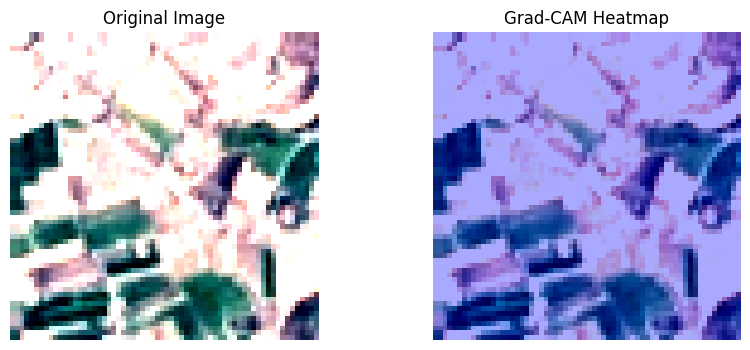

In [ ]:
#prepare image for visualization
rgb_image = image.permute(1, 2, 0).cpu().numpy()
rgb_image = np.clip(rgb_image, 0, 1)

#generate Grad-CAM for the predicted class
targets = [ClassifierOutputTarget(predicted_class.item())]
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)

#take the first image from batch
grayscale_cam = grayscale_cam[0, :]

#overlay heatmap on original image
cam_image = show_cam_on_image(rgb_image, grayscale_cam, use_rgb=True)

#plot original and Grad-CAM image
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(rgb_image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cam_image)
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.show()

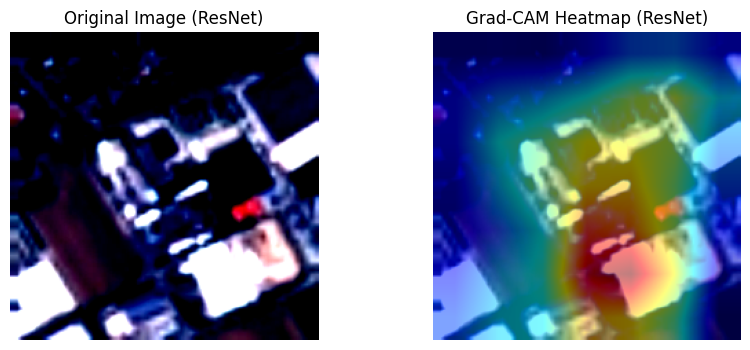

In [ ]:
#Prepare ResNet image for visualization
rgb_image_resnet = image_resnet.permute(1, 2, 0).cpu().numpy()
rgb_image_resnet = np.clip(rgb_image_resnet, 0, 1)

#Generate Grad-CAM for ResNet
targets_resnet = [ClassifierOutputTarget(predicted_class_resnet.item())]
grayscale_cam_resnet = cam_resnet(input_tensor=input_tensor_resnet, targets=targets_resnet)

#Take first image
grayscale_cam_resnet = grayscale_cam_resnet[0, :]

#Overlay heatmap
cam_image_resnet = show_cam_on_image(rgb_image_resnet, grayscale_cam_resnet, use_rgb=True)

#Plot
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(rgb_image_resnet)
plt.title("Original Image (ResNet)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cam_image_resnet)
plt.title("Grad-CAM Heatmap (ResNet)")
plt.axis("off")

plt.show()

In [ ]:
#Get confidence score for the sample prediction
probabilities = torch.softmax(outputs, dim=1)
confidence = probabilities[0, predicted_class.item()].item()

print("Predicted class:", dataset.classes[predicted_class.item()])
print("Confidence:", round(confidence, 4))

Predicted class: PermanentCrop
Confidence: 1.0


In [ ]:
#Get confidence score for ResNet prediction
probabilities_resnet = torch.softmax(outputs_resnet, dim=1)
confidence_resnet = probabilities_resnet[0, predicted_class_resnet.item()].item()

print("Predicted class (ResNet):", dataset.classes[predicted_class_resnet.item()])
print("Confidence (ResNet):", round(confidence_resnet, 4))

Predicted class (ResNet): Industrial
Confidence (ResNet): 1.0


In [ ]:
prediction_class_name = dataset.classes[predicted_class.item()]

prompt = f"""
Explain why the model predicted the class '{prediction_class_name}'
with confidence {confidence:.2f} based on Grad-CAM.

Write a short and simple explanation of why the model may have predicted this class.
Keep the explanation clear, and easy to understand.
"""

print(prompt)


Explain why the model predicted the class 'PermanentCrop'
with confidence 1.00 based on Grad-CAM.

Write a short and simple explanation of why the model may have predicted this class.
Keep the explanation clear, and easy to understand.



In [ ]:
# Prompt for ResNet explanation

prediction_class_name_resnet = dataset.classes[predicted_class_resnet.item()]

prompt_resnet = f"""
Explain why the model predicted the class '{prediction_class_name_resnet}'
with confidence {confidence_resnet:.2f} based on Grad-CAM.

Write a short and simple explanation of why the model may have predicted this class.
Keep the explanation clear and easy to understand.
"""

print(prompt_resnet)


Explain why the model predicted the class 'Industrial'
with confidence 1.00 based on Grad-CAM.

Write a short and simple explanation of why the model may have predicted this class.
Keep the explanation clear and easy to understand.



###13. Gemini API Integration

In [ ]:
!pip install -q -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 786.1/786.1 kB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.6/240.6 kB 24.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.47.0, but you have google-auth 2.49.2 which is incompatible.


In [ ]:
from google import genai
import os

In [ ]:
#set your Gemini API key
os.environ["GEMINI_API_KEY"] = userdata.get('GEMINI_API_KEY')

In [ ]:
client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

In [ ]:
try:
    response = client.models.generate_content(
        model="gemini-flash-latest",
        contents=prompt
    )
    explanation = response.text
except Exception as e:
    explanation = "AI explanation is temporarily unavailable due to API limits."
    print("Gemini error:", e)

###14. User Interface with Gradio

In [ ]:
!pip install -q gradio

In [ ]:
import gradio as gr
from PIL import Image

In [ ]:
def predict_with_explanation(uploaded_image):
    image = uploaded_image.convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
        )
    ])

    input_image = transform(image)
    input_tensor = input_image.unsqueeze(0).to(device)

    model.eval()
    outputs = model(input_tensor)
    probabilities = torch.softmax(outputs, dim=1)
    _, predicted_class = torch.max(outputs, 1)

    confidence = probabilities[0, predicted_class.item()].item()
    prediction_class_name = dataset.classes[predicted_class.item()]

    print("Inside Gradio function")
    print("Predicted class:", prediction_class_name)
    print("Confidence:", confidence)

    rgb_image = input_image.permute(1, 2, 0).cpu().numpy()
    rgb_image = np.clip(rgb_image, 0, 1)

    targets = [ClassifierOutputTarget(predicted_class.item())]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    cam_image = show_cam_on_image(rgb_image, grayscale_cam, use_rgb=True)

    prompt = f"""
    Explain why the CNN model predicted the class: {prediction_class_name}
    The confidence score is: {confidence:.2f}

    Write a short and simple explanation of why the model may have predicted this class.
    Keep the explanation clear, and easy to understand.
    """

    response = client.models.generate_content(
        model="gemini-flash-latest",
        contents=prompt
    )

    explanation = response.text

    return prediction_class_name, f"{confidence:.2f}", cam_image, explanation

In [ ]:
interface = gr.Interface(
    fn=predict_with_explanation,
    inputs=gr.Image(type="pil", label="Upload Satellite Image"),
    outputs=[
        gr.Textbox(label="Predicted Class"),
        gr.Textbox(label="Confidence"),
        gr.Image(label="Grad-CAM Heatmap"),
        gr.Textbox(label="AI Explanation")
    ],
    title="Satellite Image Classification",
    description="Upload a satellite image to get the predicted class, confidence, Grad-CAM heatmap, and AI-generated explanation."
)

In [ ]:
interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://04ab150a6a4c4e5596.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
